Part 3: NLP and Sequence Modeling Mini Project

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


  ticket_id channel                                   customer_message  \
0  TKT00001    chat  I need information about the payment process. ...   
1  TKT00002   phone      I need information about the payment process.   
2  TKT00003   email  The refund process was fast and convenient. I ...   
3  TKT00004  social  My refund is still pending and this experience...   
4  TKT00005    chat   Please tell me how to update my account details.   

  sentiment_label  word_count  urgent_flag  
0         neutral          18            1  
1         neutral           7            0  
2        positive          12            0  
3        negative          15            1  
4         neutral           9            0  

DATASET UNDERSTANDING

Total Records:
1500

Target Classes:
['neutral' 'positive' 'negative']

Sample Customer Messages:
0    I need information about the payment process. ...
1        I need information about the payment process.
2    The refund process was fast and convenient. I ..

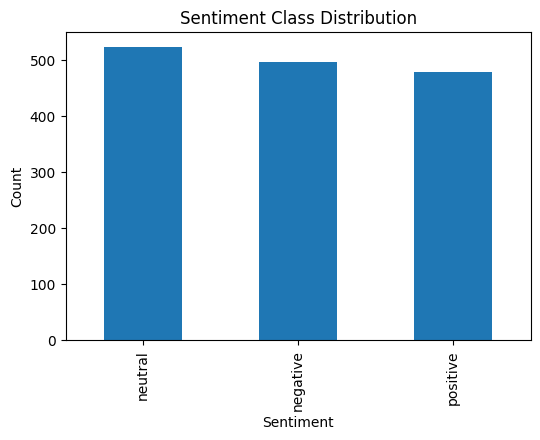


TEXT PREPROCESSING

Original vs Cleaned Text:
                                    customer_message  \
0  I need information about the payment process. ...   
1      I need information about the payment process.   
2  The refund process was fast and convenient. I ...   
3  My refund is still pending and this experience...   
4   Please tell me how to update my account details.   

                                          clean_text  
0  need information payment process ticket number...  
1                   need information payment process  
2  refund process fast convenient appreciate quic...  
3  refund still pending experience frustrating ti...  
4                 please tell update account details  

TEXT VECTORIZATION

TF-IDF Shape:
(1500, 146)

BASELINE MODEL

Model Accuracy:
1.0

Classification Report:
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00       109
     neutral       1.00      1.00      1.00       104
    positive   

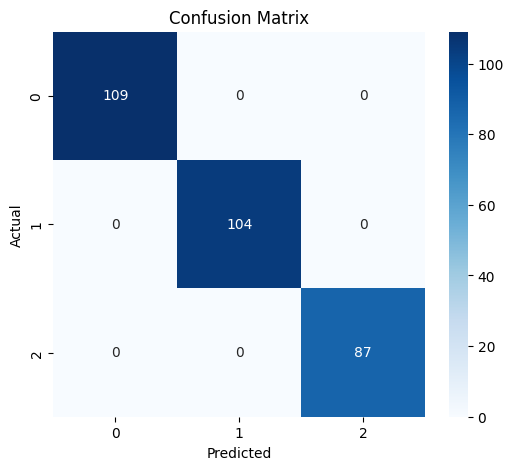


LSTM SEQUENCE MODEL

LSTM Model Summary:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 72ms/step - accuracy: 0.3354 - loss: 1.1008 - val_accuracy: 0.3292 - val_loss: 1.1001
Epoch 2/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 87ms/step - accuracy: 0.3552 - loss: 1.0985 - val_accuracy: 0.3292 - val_loss: 1.1002
Epoch 3/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - accuracy: 0.3469 - loss: 1.0993 - val_accuracy: 0.3292 - val_loss: 1.1008
Epoch 4/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - accuracy: 0.3552 - loss: 1.0999 - val_accuracy: 0.3292 - val_loss: 1.0992
Epoch 5/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - accuracy: 0.3552 - loss: 1.0981 - val_accuracy: 0.3292 - val_loss: 1.0992
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.3467 - loss: 1.0991

LSTM Test Accuracy:
0.3466666638851166

SAMPLE PREDICTIONS
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step

Text: The support team solved my issue quickly
Predicted Sentiment: neutral

Text: I am unhappy with the service
Predicted Sentiment: neutral

Text: The response was okay
Predicted Sentiment: neut

In [4]:
# ============================================
# PART 3: NLP AND SEQUENCE MODELING MINI PROJECT
# Customer Support Text Classification
# ============================================

# ============================================
# STEP 1: IMPORT LIBRARIES
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

# Download NLTK resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

# ============================================
# STEP 2: LOAD DATASET
# ============================================

# Upload the CSV file in Google Colab first
# Then run this code

df = pd.read_csv('/content/customer_support_text_classification.csv')

# Display first 5 rows
print(df.head())

# ============================================
# TASK 1: DATASET UNDERSTANDING
# ============================================

print("\n==============================")
print("DATASET UNDERSTANDING")
print("==============================")

# Number of records
print("\nTotal Records:")
print(len(df))

# Target labels/classes
print("\nTarget Classes:")
print(df['sentiment_label'].unique())

# Sample text records
print("\nSample Customer Messages:")
print(df['customer_message'].head())

# Average text length
df['text_length'] = df['customer_message'].apply(
    lambda x: len(str(x).split())
)

print("\nAverage Text Length:")
print(df['text_length'].mean())

# Class distribution
print("\nClass Distribution:")
print(df['sentiment_label'].value_counts())

# Visualization
plt.figure(figsize=(6,4))

df['sentiment_label'].value_counts().plot(kind='bar')

plt.title("Sentiment Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()

# ============================================
# TASK 2: TEXT PREPROCESSING
# ============================================

print("\n==============================")
print("TEXT PREPROCESSING")
print("==============================")

stop_words = set(stopwords.words('english'))

# Text cleaning function
def preprocess_text(text):

    # Convert to lowercase
    text = str(text).lower()

    # Remove special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Tokenization
    tokens = word_tokenize(text)

    # Remove stopwords
    tokens = [
        word for word in tokens
        if word not in stop_words
    ]

    # Join words back
    return " ".join(tokens)

# Apply preprocessing
df['clean_text'] = df['customer_message'].apply(preprocess_text)

# Show original vs cleaned text
print("\nOriginal vs Cleaned Text:")
print(df[['customer_message', 'clean_text']].head())

# ============================================
# TASK 3: TEXT VECTORIZATION
# ============================================

print("\n==============================")
print("TEXT VECTORIZATION")
print("==============================")

# TF-IDF Vectorization
vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df['clean_text'])

y = df['sentiment_label']

print("\nTF-IDF Shape:")
print(X.shape)

# ============================================
# TASK 4: BASELINE MODEL
# Logistic Regression + TF-IDF
# ============================================

print("\n==============================")
print("BASELINE MODEL")
print("==============================")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Create model
lr_model = LogisticRegression(max_iter=1000)

# Train model
lr_model.fit(X_train, y_train)

# Predictions
y_pred = lr_model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("\nModel Accuracy:")
print(accuracy)

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# ============================================
# TASK 5: SEQUENCE MODEL (LSTM)
# ============================================

print("\n==============================")
print("LSTM SEQUENCE MODEL")
print("==============================")

# Tokenizer
tokenizer = Tokenizer(num_words=5000)

tokenizer.fit_on_texts(df['clean_text'])

# Convert text to sequences
sequences = tokenizer.texts_to_sequences(df['clean_text'])

# Padding sequences
max_length = 100

X_seq = pad_sequences(
    sequences,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

# Encode labels
encoder = LabelEncoder()

y_encoded = encoder.fit_transform(y)

# Train-test split
X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(
    X_seq,
    y_encoded,
    test_size=0.2,
    random_state=42
)

# ============================================
# BUILD LSTM MODEL
# ============================================

lstm_model = Sequential([

    Embedding(
        input_dim=5000,
        output_dim=128,
        input_length=max_length
    ),

    LSTM(64),

    Dense(32, activation='relu'),

    Dense(3, activation='softmax')
])

# Compile model
lstm_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Model summary
print("\nLSTM Model Summary:")
lstm_model.summary()

# ============================================
# TRAIN MODEL
# ============================================

history = lstm_model.fit(
    X_train_seq,
    y_train_seq,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

# ============================================
# EVALUATE MODEL
# ============================================

loss, accuracy = lstm_model.evaluate(
    X_test_seq,
    y_test_seq
)

print("\nLSTM Test Accuracy:")
print(accuracy)

# ============================================
# SAMPLE PREDICTIONS
# ============================================

print("\n==============================")
print("SAMPLE PREDICTIONS")
print("==============================")

sample_texts = [
    "The support team solved my issue quickly",
    "I am unhappy with the service",
    "The response was okay"
]

# Preprocess sample texts
sample_clean = [
    preprocess_text(text)
    for text in sample_texts
]

# Convert to sequence
sample_seq = tokenizer.texts_to_sequences(sample_clean)

# Pad sequences
sample_pad = pad_sequences(
    sample_seq,
    maxlen=max_length,
    padding='post'
)

# Predict
predictions = lstm_model.predict(sample_pad)

# Convert prediction to labels
predicted_labels = encoder.inverse_transform(
    np.argmax(predictions, axis=1)
)

# Display predictions
for text, label in zip(sample_texts, predicted_labels):

    print("\nText:", text)
    print("Predicted Sentiment:", label)

# ============================================
# TASK 6: REFLECTION QUESTIONS
# ============================================

print("\n==============================")
print("REFLECTION")
print("==============================")

print("""
1. Why RNNs struggle with long-term dependencies:
RNNs suffer from vanishing gradients and tend to forget earlier information
in long sequences.

2. How LSTMs help:
LSTMs use memory cells and gates to retain important information for longer
periods.

3. What attention solves:
Attention helps models focus on the most relevant words in a sequence instead
of relying only on the final hidden state.

4. Why transformers are important:
Transformers process sequences in parallel using self-attention, making them
faster and more effective for modern NLP tasks.
""")

print("\nPROJECT COMPLETED SUCCESSFULLY")

# New Section